## Load Uncalibrated Config

In [2]:
from pathlib import Path
import json 
import pandas as pd

DATA_FOLDER = Path('../experiments/20240730_bravo')

with open(DATA_FOLDER / 'old_reactor_config.json') as f: 
    cfg = json.load(f)

# write default None values 
inc_temp_slope, inc_temp_intercept = cfg['incubator_temp']['slope'], cfg['incubator_temp']['intercept']
lagoon_temp_slope, lagoon_temp_intercept = cfg['lagoon_temp']['slope'], cfg['lagoon_temp']['intercept']
od_slope, od_intercept = cfg['incubator_od']['slope'], cfg['incubator_od']['intercept']
actual_burst_vol = cfg['pump_incubator_to_lagoon_burst_vol_ml']
lagoon_stirrer_top_speed_frac = cfg['lagoon_stirrer_top_speed_frac']
inc_stirrer_top_speed_frac = cfg['incubator_stirrer_top_speed_frac']
stepper_rotation_direction = cfg['stepper_direction']
cfg

{'incubator_od': {'intercept': -11.59205539167169,
  'slope': 0.00019927860804722363},
 'incubator_temp': {'intercept': -3.2129495472186207,
  'slope': 1.1653298835705044},
 'lagoon_temp': {'intercept': -4.825295203092907, 'slope': 1.2057411122068846},
 'incubator_stirrer_top_speed_frac': 0.3,
 'lagoon_stirrer_top_speed_frac': 0.4,
 'pumps_speed_frac': 0.4,
 'pump_incubator_to_lagoon_burst_vol_ml': 0.1740618000000002,
 'pump_incubator_to_lagoon_burst_duration_s': 0.5,
 'pump_lagoon_to_waste_burst_duration_s': 0.6,
 'induction_ml_per_step': 0.001511259,
 'stepper_direction': 1}

In [3]:
from sklearn.linear_model import LinearRegression
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

def linear_fit_1d(df, x, y, show_plot=True, x_std=None, y_std=None): 
    X = df[[x]]  # Feature matrix
    Y = df[y]  # Target variable
    model = LinearRegression().fit(X, Y)
    y_pred = model.predict(X)
    slope = model.coef_[0]  # Assuming there's only one feature
    intercept = model.intercept_
    if show_plot:
        plt.scatter(df[x], df[y], color='green')
        plt.plot(df[x], y_pred, color='red', label='prediction')
        if y_std: 
            plt.errorbar(df[x], df[y], yerr=df[y_std], fmt='o', color='green')
        if x_std: 
            plt.errorbar(df[x], df[y], xerr=df[x_std], fmt='o', color='green')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.legend()
        plt.show()
    return slope, intercept

## Temperature Calibration

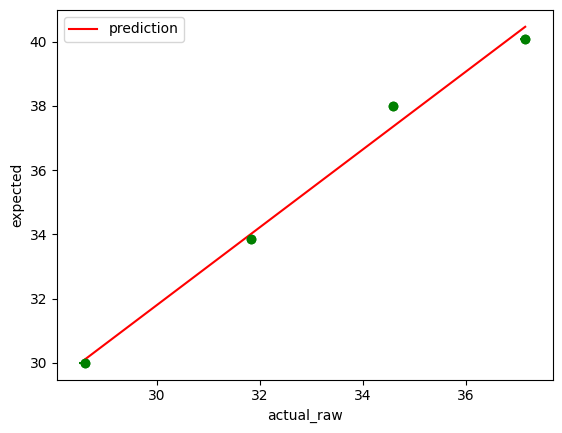

Old inc temp slope: 1.17, intercept: -3.21
New inc temp slope: 1.21, intercept: -4.57


In [20]:



inc_temp = pd.DataFrame({'expected': [30.0, 33.86, 38, 40.07], 'actual_raw': [28.6, 31.83, 34.59, 37.15], 'actual_std': [0.1, 0.04, 0.02, 0.1]})
inc_temp_slope, inc_temp_intercept = linear_fit_1d(inc_temp, x='actual_raw', y='expected', x_std='actual_std')
print(f'Old inc temp slope: {cfg["incubator_temp"]["slope"]:.2f}, intercept: {cfg["incubator_temp"]["intercept"]:.2f}')
print(f'New inc temp slope: {inc_temp_slope:.2f}, intercept: {inc_temp_intercept:.2f}')


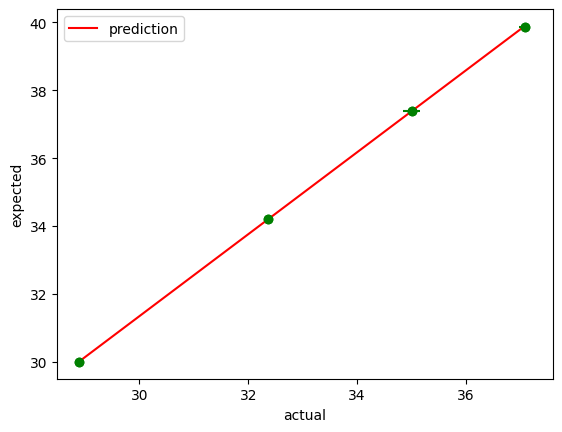

Old lagoon temp slope: 1.21, intercept: -4.83
New lagoon temp slope: 1.21, intercept: -4.87


In [21]:
lagoon_temp = pd.DataFrame({'expected': [30, 34.22, 37.40, 39.87], 'actual': [28.9, 32.36, 35.0, 37.08], 'actual_std': [0.0, 0.04, 0.16, 0.1]})

lagoon_temp_slope, lagoon_temp_intercept =  linear_fit_1d(lagoon_temp, x='actual', y='expected', x_std='actual_std')
print(f'Old lagoon temp slope: {cfg["lagoon_temp"]["slope"]:.2f}, intercept: {cfg["lagoon_temp"]["intercept"]:.2f}')
print(f'New lagoon temp slope: {lagoon_temp_slope:.2f}, intercept: {lagoon_temp_intercept:.2f}')

## OD Calibration

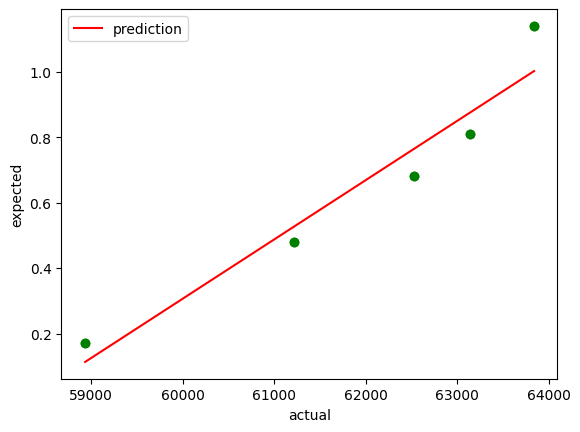

Old OD slope: 0.00020, intercept: -11.59206
New OD slope: 0.00018, intercept: -10.57501


In [4]:
measured_od = pd.read_csv(DATA_FOLDER / 'od.csv', header=None)
od_mean = measured_od.mean(axis=1)
od_std = measured_od.std(axis=1)
od = pd.DataFrame({'expected': [0.17, 0.48, 0.68, 0.81, 1.14], 'actual': od_mean, 'actual_std': od_std})

od_slope, od_intercept = linear_fit_1d(od, x='actual', y='expected', x_std='actual_std')
print(f"Old OD slope: {cfg['incubator_od']['slope']:.5f}, intercept: {cfg['incubator_od']['intercept']:.5f}")
print(f"New OD slope: {od_slope:.5f}, intercept: {od_intercept:.5f}")

## Pump Calibration

In [5]:
target_vol = 50
actual_vol = 150.81 - 106.32
print(f'Target volume = {target_vol} mL, Actual volume = {actual_vol} mL')

expected_burst_vol = cfg["pump_incubator_to_lagoon_burst_vol_ml"]

actual_burst_vol = actual_vol / (target_vol / expected_burst_vol)
print(f'Old burst volume = {expected_burst_vol:.3f} mL')
print(f'New Burst volume = {actual_burst_vol:.3f} mL') 

Target volume = 50 mL, Actual volume = 44.49000000000001 mL
Old burst volume = 0.174 mL
New Burst volume = 0.155 mL


## Stirrer Speed calibration

In [7]:
with open(DATA_FOLDER / 'inc_stirrer_speed_frac.txt', 'r') as f:
    inc_stirrer_top_speed_frac = float(f.read())

lagoon_stirrer_top_speed_frac = 0.35
inc_stirrer_top_speed_frac, lagoon_stirrer_top_speed_frac

(0.25, 0.35)

## Stepper Direction calibration

In [9]:
with open(DATA_FOLDER / 'stepper_rotation_direction.txt', 'r') as f: 
    stepper_rotation_direction = int(f.read())

assert stepper_rotation_direction in {1, -1}, f'Unknown stepper rotation direction {stepper_rotation_direction}'

## Update Config

In [10]:
new_cfg = cfg.copy()
new_cfg['incubator_temp']['slope'] = inc_temp_slope
new_cfg['incubator_temp']['intercept'] = inc_temp_intercept
new_cfg['lagoon_temp']['slope'] = lagoon_temp_slope
new_cfg['lagoon_temp']['intercept'] = lagoon_temp_intercept
new_cfg['incubator_od']['slope'] = od_slope
new_cfg['incubator_od']['intercept'] = od_intercept
new_cfg['pump_incubator_to_lagoon_burst_vol_ml'] = actual_burst_vol
new_cfg['incubator_stirrer_top_speed_frac'] = inc_stirrer_top_speed_frac
new_cfg['lagoon_stirrer_top_speed_frac'] = lagoon_stirrer_top_speed_frac
new_cfg['stepper_direction'] = stepper_rotation_direction

with open(DATA_FOLDER / 'new_reactor_config.json', 'w') as f:
    json.dump(new_cfg, f, indent=2)

new_cfg

{'incubator_od': {'intercept': -10.575014999547601,
  'slope': 0.00018135437025417034},
 'incubator_temp': {'intercept': -3.2129495472186207,
  'slope': 1.1653298835705044},
 'lagoon_temp': {'intercept': -4.825295203092907, 'slope': 1.2057411122068846},
 'incubator_stirrer_top_speed_frac': 0.25,
 'lagoon_stirrer_top_speed_frac': 0.35,
 'pumps_speed_frac': 0.4,
 'pump_incubator_to_lagoon_burst_vol_ml': 0.15488018964000022,
 'pump_incubator_to_lagoon_burst_duration_s': 0.5,
 'pump_lagoon_to_waste_burst_duration_s': 0.6,
 'induction_ml_per_step': 0.001511259,
 'stepper_direction': 1}